In this one, in the end I show a p value that shows that there is more correlaiton for the last digits

In [12]:
from __future__ import annotations
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cross_decomposition import CCA

###############################################################################
# Paths & constants
###############################################################################
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_processed_clara")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed2")

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

OUT_TRIALS  = Path("trial_level_cca_fixedlag.csv")
OUT_SUBJECT = Path("subject_best_lag.csv")

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
#SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SHIFTS = np.arange(-100, 101)      # ±1 s at 100 Hz → samples
WIN_OFFSET1 = 200                  # discard first 200 ms
WIN_OFFSET2 = 110                  # discard last 110 ms

###############################################################################
# Helper functions
###############################################################################

def normalise_eeg(x: np.ndarray) -> np.ndarray:
    """Centre each channel and scale so Σ x² = 1 over time×channels."""
    x = x - x.mean(axis=0, keepdims=True)
    scale = np.sqrt(np.mean(x**2))
    return x / scale


def cca_corr(eeg: np.ndarray, pupil: np.ndarray) -> float:
    """Canonical correlation (single component)."""
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(eeg, pupil)
    u, v = cca.transform(eeg, pupil)
    return float(np.corrcoef(u[:, 0], v[:, 0])[0, 1])


In [2]:
def load_all_trials(
        sub: int,
        eeg_root: Path = EEG_ROOT,
        pupil_root: Path = PUPIL_ROOT,
        min_len: int = 40,
        max_len_diff: int = 30,
) -> list[tuple[np.ndarray, np.ndarray, dict]]:
    """
    Load *all* valid EEG-pupil trial pairs for one subject.

    Parameters
    ----------
    sub : int
        Numeric subject ID (e.g. 42).
    eeg_root, pupil_root : Path
        Roots of the pre-processed EEG and pupil folders.
    min_len : int
        Minimum number of samples a pupil trace must have to be accepted.
    max_len_diff : int
        Reject trial if |len(pupil)-len(eeg)| exceeds this.
    Returns
    -------
    trials : list of (eeg, pupil_z, meta)
        * eeg        – (T × n_channels) float64, already centred/scaled
        * pupil_z    – (T × 1) float64, per-trial z-scored
        * meta       – dict with subject/condition/load/epoch
    """
    trials = []
    sub_tag = f"sub-{sub:03d}"
    eeg_sub  = eeg_root   / sub_tag
    pupil_sub = pupil_root / sub_tag

    if not eeg_sub.exists():
        print(f"{sub_tag}: EEG folder missing - skipped")
        return trials

    # iterate condition (“control” / “memory”) and load (“05” / “09” / “13”)
    for cond_path in sorted(eeg_sub.iterdir()):
        if not cond_path.is_dir():
            continue
        for load_path in sorted(cond_path.iterdir()):
            if not load_path.is_dir():
                continue

            # matching pupil directory
            pupil_path = pupil_sub / cond_path.name / load_path.name
            if not pupil_path.exists():
                continue

            eeg_epochs   = sorted(load_path.glob("trial_*.csv"))
            pupil_epochs = sorted(pupil_path.glob("trial_*.csv"))
            common = {f.name for f in eeg_epochs} & {f.name for f in pupil_epochs}
            if not common:
                continue

            for fname in sorted(common):
                eeg_df = pd.read_csv(load_path / fname, comment="#", index_col=0)
                pupil_df = pd.read_csv(pupil_path / fname, comment="#",
                                       names=["time", "diameter_z"], index_col=0)

                eeg   = eeg_df.values.astype(float)
                pupil = pupil_df["diameter_z"].values.astype(float)

                # basic validity checks
                if len(pupil) < min_len or abs(len(pupil) - len(eeg)) > max_len_diff:
                    continue

                # normalise signals ----------------------------------------
                eeg_norm = normalise_eeg(eeg)           # your helper from before
                pupil_z  = ((pupil - pupil.mean()) / pupil.std(ddof=0))

                # same number of samples
                T = min(len(eeg_norm), len(pupil_z))
                eeg_norm = eeg_norm[0:T, :]  # (T × n_channels)
                pupil_z  = pupil_z[0:T].reshape(-1, 1)

                meta = {
                    "subject":   sub_tag,
                    "condition": cond_path.name,
                    "load":      int(load_path.name),
                    "epoch":     fname
                }
                trials.append((eeg_norm, pupil_z, meta))

    return trials

from typing import List, Tuple
import numpy as np

def split_trials_by_condition(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        memory_label: str = "memory",
        control_label: str = "control"
) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into memory-condition and control-condition sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'condition'.
    memory_label : str
        The value of meta['condition'] that marks a memory trial.
    control_label : str
        The value of meta['condition'] that marks a control trial.

    Returns
    -------
    memory_trials  : list[tuple]
    control_trials : list[tuple]
    """
    memory_trials  = []
    control_trials = []

    for eeg, pupil, meta in trials:
        cond = meta.get("condition", "").lower()
        if cond == memory_label:
            memory_trials.append((eeg, pupil, meta))
        elif cond == control_label:
            control_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown condition label: {cond}")

    return memory_trials, control_trials


In [3]:
import numpy as np
from typing import List, Tuple, Dict

def search_best_lag(
        train_trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        shifts: np.ndarray = SHIFTS,
        return_curve: bool = False
) -> Tuple[float, int, Dict[int, float] | None]:
    """
    Search for the lag (sample shift) that maximises the mean canonical
    correlation between EEG and pupil traces in a training set.

    Parameters
    ----------
    train_trials : list of (eeg, pupil_z, meta)
        Each eeg  : 2-D array [time × channels or CCA-components]
        Each pupil: 1-D array [time]
    shifts : np.ndarray
        Array of integer lag shifts (positive = EEG is moved forward).
    return_curve : bool, default False
        If True, also return the full {shift: mean_r} dictionary.

    Returns
    -------
    best_corr : float
        Highest mean canonical correlation found.
    best_shift : int
        Shift (samples) that maximised the correlation.
    mean_r_per_shift : dict | None
        Only when `return_curve` is True.
    """
    win = slice(WIN_OFFSET1, -WIN_OFFSET2)         # common window
    mean_r_per_shift: Dict[int, float] = {}

    for s in shifts:                               # <-- loop over *shifts*, not SHIFTS
        rs = []
        for eeg, pupil_z, _ in train_trials:
            eeg_shifted = np.roll(eeg, s, axis=0)[win]
            r = cca_corr(eeg_shifted, pupil_z[win])
            rs.append(r)
        mean_r_per_shift[s] = float(np.mean(rs))   # cast to plain float for JSON-ability

    best_shift = max(mean_r_per_shift, key=mean_r_per_shift.get)
    best_corr  = mean_r_per_shift[best_shift]

    if return_curve:
        return best_corr, best_shift, mean_r_per_shift
    else:
        return best_corr, best_shift, None


In [4]:

from typing import List, Tuple, Optional

# trials  : list of (eeg, pupil_z, meta)   –– the tuples returned by load_all_trials
# shift   : integer sample shift (best_shift)
# win     : slice or None                  –– cropping window (set to None if the
#                                            trials are already pre-trimmed)
def concat_trials(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        shift: int = 0,
        win: Optional[slice] = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Concatenate a list of trials into one long matrix pair ready for CCA.

    Returns
    -------
    X  : ndarray, shape (Σ Tᵢ, n_channels)
    Y  : ndarray, shape (Σ Tᵢ, 1)
    """
    X_blocks, Y_blocks = [], []

    for eeg, pupil_z, _ in trials:
        # 1. roll *inside* the trial so samples never cross trial boundaries
        eeg_shift = np.roll(eeg, shift, axis=0)

        # 2. optional windowing (do it once here if you did **not** crop in loader)
        if win is not None:
            eeg_shift = eeg_shift[win]
            pupil_seg = pupil_z[win]
        else:
            pupil_seg = pupil_z          # already trimmed earlier

        # 3. stack
        X_blocks.append(eeg_shift)
        Y_blocks.append(pupil_seg)

    X = np.vstack(X_blocks)
    Y = np.vstack(Y_blocks)
    return X, Y

def iterate_trials(trials, shift, win):
    """Yield (eeg_shifted, pupil_z_windowed, meta) one by one."""
    for eeg, pupil_z, meta in trials:
        eeg_s = np.roll(eeg, shift, axis=0)[win]
        yield eeg_s, pupil_z[win], meta.copy()

import pandas as pd
import json
from pathlib import Path

def save_cca_weights(cca, subject_tag, lag_ms, eeg_ch_names, condition, out_dir=Path("weights")):
    """
    Dump EEG & pupil canonical weights to CSV/JSON for one subject.

    Parameters
    ----------
    cca            : fitted sklearn.cross_decomposition.CCA
    subject_tag    : "sub-042"
    lag_ms         : e.g. -90
    eeg_ch_names   : list[str] same order as columns in your trial matrices
    out_dir        : destination folder (created if missing)
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    # ------- Pupil weight -> JSON ---------------------------------------
    w_pupil = float(cca.y_weights_[0, 0])   # scalar in 1-dim pupil case
    w_pupil = w_pupil / w_pupil
    with open(out_dir / f"{subject_tag}_pupil_weight_{condition}_{lag_ms:+d}ms.json", "w") as fh:
        json.dump({"weight": w_pupil}, fh, indent=2)
    
    # ------- EEG weights -> tidy CSV ------------------------------------
    w_eeg = cca.x_weights_[:, 0] / w_pupil
    w_eeg = pd.Series(w_eeg, index=eeg_ch_names, name="weight")
    w_eeg.index.name = "channel"
    w_eeg.to_csv(out_dir / f"{subject_tag}_eeg_weights_{condition}_{lag_ms:+d}ms.csv")

    print(f"saved weights for {subject_tag} (lag {lag_ms:+d} ms)")



Subject 33: best lag -50 ms with r = 0.480
Subject 34: best lag 320 ms with r = 0.470


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\

Subject 35: best lag -80 ms with r = 0.542
Subject 36: best lag -590 ms with r = 0.492
Subject 38: best lag -10 ms with r = 0.488
Subject 39: best lag 20 ms with r = 0.501
Subject 40: best lag 1000 ms with r = 0.512
Subject 41: best lag -100 ms with r = 0.477
Subject 42: best lag -800 ms with r = 0.496


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\

Subject 43: best lag 700 ms with r = 0.519
Subject 44: best lag -100 ms with r = 0.475
Subject 45: best lag 420 ms with r = 0.472
Subject 46: best lag -680 ms with r = 0.561


...

Subject 91: best lag -50 ms with r = 0.513
Subject 92: best lag 410 ms with r = 0.545


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Subject 93: best lag 1000 ms with r = 0.500
Subject 95: best lag -70 ms with r = 0.493


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Subject 97: best lag -560 ms with r = 0.544
Subject 98: best lag 690 ms with r = 0.452
Finished - saved per-trial correlations with plain CCA.


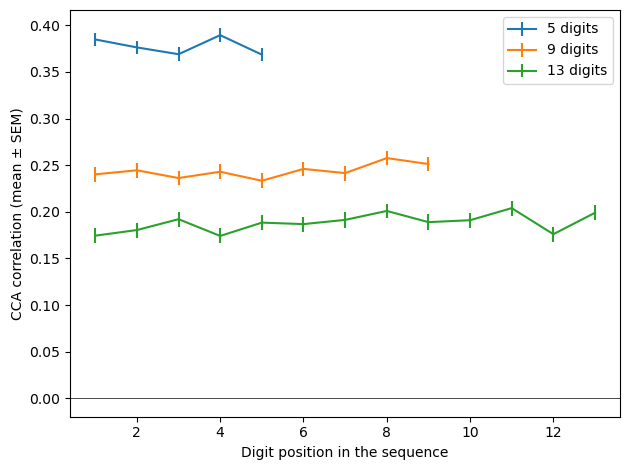

In [13]:
import matplotlib.pyplot as plt

all_rows = []  # collect all trial-level results here
best_shift_by_sub = {}  # best shift per subject
DIG_LEN   = 200           # 2 s at 100 Hz
rows_trials = []

for subj in SUBJECTS:
    trials = load_all_trials(subj)                         # list of (eeg, pupil)
    trials_memory, trials_control = split_trials_by_condition(trials)
    
    # ----- lag search on memory ------------------------------------------
    return_curve = False  # set to True if you want the full curve
    best_corr, best_shift, mean_r_per_shift = search_best_lag(trials_memory, SHIFTS, return_curve)
    print(f"Subject {subj:02d}: best lag {best_shift*10} ms with r = {best_corr:.3f}")
    best_shift_by_sub[subj] = best_shift      # samples, not ms

    if return_curve:
        # -------------------------------------------------------------
        # 2) Build x and y vectors for plotting
        # -------------------------------------------------------------
        lags   = np.array(sorted(mean_r_per_shift))                 # x-axis (samples)
        r_mean = np.array([mean_r_per_shift[s] for s in lags])      # y-axis (mean r)

        # If you prefer milliseconds instead of samples:
        # fs = 1000  # replace with your real sampling rate
        # lags = lags * 1000 / fs

        # -------------------------------------------------------------
        # 3) Plot
        # -------------------------------------------------------------
        import matplotlib.pyplot as plt

        plt.figure(figsize=(6, 3.5))
        plt.plot(lags, r_mean, lw=2)
        plt.axvline(best_shift, ls='--', lw=1.5,
                    label=f'best lag = {best_shift}')
        plt.xlabel('Lag (samples)')
        plt.ylabel('Mean canonical correlation (r)')
        plt.title('Mean CCA correlation vs. lag')
        plt.grid(alpha=.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


    # ----- fit weights ONCE using all train trials at best_shift ---------
    win = slice(WIN_OFFSET1, -WIN_OFFSET2)


    # ----- per-trial r on TEST with frozen lag & weights -----------------
    for eeg_s, pupil_s, meta in iterate_trials(trials_memory, best_shift, win):
        n_digits = meta['load']
        for d in range(n_digits):
            w = slice(d*DIG_LEN, (d+1)*DIG_LEN)

        cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
        cca.fit(eeg_s, pupil_s)
        cv_eeg, cv_pupil = cca.transform(eeg_s, pupil_s)
        cv_eeg = cv_eeg[:, 0]  # first CCA component
        cv_pupil = cv_pupil[:, 0]  # first CCA component

        for d in range(n_digits):
            w = slice(d * DIG_LEN, (d + 1) * DIG_LEN)
            r = np.corrcoef(cv_eeg[w], cv_pupil[w])[0, 1]
            rows_trials.append({
                'subject': meta['subject'],
                'condition': meta['condition'],
                'load': meta['load'],
                'epoch': meta['epoch'],
                'lag_ms': best_shift * 10,  # convert samples to ms
                'digit_pos': d + 1,  # 1-based digit index
                'r': float(r),  # convert to plain float for JSON-ability
            })

        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['lag_ms'] = best_shift *10
        all_rows.append(meta)

df = pd.DataFrame(rows_trials)
grand = (df.query("condition == 'memory'")
           .groupby(['load','digit_pos'])['r']
           .agg(['mean','sem'])
           .reset_index())

for L in [5,9,13]:
    sub = grand[grand.load == L]
    plt.errorbar(sub.digit_pos, sub['mean'],
                 yerr=sub['sem'], label=f"{L} digits")
plt.axhline(0, c='k', lw=.5)
plt.xlabel("Digit position in the sequence")
plt.ylabel("CCA correlation (mean ± SEM)")
plt.legend(); plt.tight_layout()

##############################################################################
# ---- save -----------------------------------------------------------------
##############################################################################
pd.DataFrame(all_rows).to_csv("trial_level_cca_fixedlag_splitCV3.csv", index=False)
print("Finished - saved per-trial correlations with plain CCA.")


In [16]:
import pandas as pd
import numpy as np

# keep only MEMORY trials and clip r to avoid ±∞ after Fisher-z
df_mem = (df.query("condition == 'memory'")
            .assign(z = lambda d: np.arctanh(
                d.r.clip(lower=-0.999_999, upper=0.999_999))))


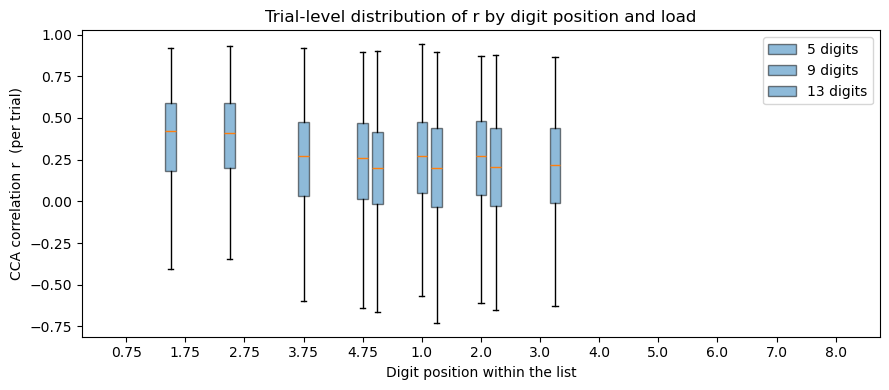

In [22]:
import matplotlib.pyplot as plt

loads   = sorted(df_mem.load.unique())      # [5, 9, 13]
digits  = sorted(df_mem.digit_pos.unique()) # 1 … 13
offset  = 0.25                              # separates the three loads a bit

plt.figure(figsize=(9, 4))

for j, L in enumerate(loads):               # j = 0,1,2 → −1×off, 0, +1×off
    shift = (j - 1) * offset
    for d in digits:
        vals = df_mem.query("load == @L and digit_pos == @d").r
        if vals.empty:        # load 5 has no digits 6-13, etc.
            continue
        x_pos = d + shift
        plt.boxplot(vals, positions=[x_pos], widths=0.18,
                    showfliers=False, patch_artist=True,
                    boxprops=dict(alpha=0.5))

plt.xticks(digits)
plt.xlabel("Digit position within the list")
plt.ylabel("CCA correlation r  (per trial)")
plt.title("Trial-level distribution of r by digit position and load")
plt.legend([f"{L} digits" for L in loads], loc="upper right")
plt.tight_layout()
plt.show()


In [23]:
import statsmodels.formula.api as smf
import statsmodels.stats.anova as sm_anova

for L in loads:
    wide = (df_mem.query("load == @L")
                   .pivot_table(index="subject",
                                columns="digit_pos",
                                values="r",
                                aggfunc="mean")
                   .dropna())          # subject must have every digit

    long = wide.reset_index().melt(id_vars='subject',
                                   var_name='digit_pos',
                                   value_name='r')

    model = smf.ols("r ~ C(digit_pos) + C(subject)", data=long).fit()
    anova = sm_anova.anova_lm(model, typ=2)
    print(f"\n=== Load {L} digits ===")
    print(anova.loc["C(digit_pos)"])



=== Load 5 digits ===
sum_sq    0.045436
df        4.000000
F         2.452482
PR(>F)    0.046875
Name: C(digit_pos), dtype: float64

=== Load 9 digits ===
sum_sq    0.044709
df        8.000000
F         0.917199
PR(>F)    0.501867
Name: C(digit_pos), dtype: float64

=== Load 13 digits ===
sum_sq     0.095648
df        12.000000
F          0.726205
PR(>F)     0.726404
Name: C(digit_pos), dtype: float64


In [26]:
from itertools import combinations
from scipy.stats import ttest_rel

load5 = (df_mem.query("load == 13")
                   .groupby(['subject', 'digit_pos'])['r'].mean()
                   .unstack())    # subjects × 5 positions

for a, b in combinations(load5.columns, 2):
    t, p = ttest_rel(load5[a], load5[b], nan_policy='omit')
    print(f"digit {a} vs {b}: t = {t:.2f},  p = {p:.3f}")


digit 1 vs 2: t = -0.49,  p = 0.628
digit 1 vs 3: t = -1.41,  p = 0.163
digit 1 vs 4: t = -0.26,  p = 0.796
digit 1 vs 5: t = -0.10,  p = 0.922
digit 1 vs 6: t = -1.59,  p = 0.117
digit 1 vs 7: t = -1.47,  p = 0.147
digit 1 vs 8: t = -0.60,  p = 0.549
digit 1 vs 9: t = -1.48,  p = 0.146
digit 1 vs 10: t = -2.14,  p = 0.037
digit 1 vs 11: t = -0.76,  p = 0.449
digit 1 vs 12: t = -0.39,  p = 0.702
digit 1 vs 13: t = -1.46,  p = 0.149
digit 2 vs 3: t = -1.10,  p = 0.276
digit 2 vs 4: t = 0.17,  p = 0.869
digit 2 vs 5: t = 0.23,  p = 0.818
digit 2 vs 6: t = -1.33,  p = 0.189
digit 2 vs 7: t = -0.95,  p = 0.346
digit 2 vs 8: t = -0.28,  p = 0.778
digit 2 vs 9: t = -1.36,  p = 0.179
digit 2 vs 10: t = -2.10,  p = 0.040
digit 2 vs 11: t = -0.56,  p = 0.575
digit 2 vs 12: t = -0.10,  p = 0.922
digit 2 vs 13: t = -1.44,  p = 0.157
digit 3 vs 4: t = 0.88,  p = 0.381
digit 3 vs 5: t = 0.80,  p = 0.425
digit 3 vs 6: t = -0.38,  p = 0.703
digit 3 vs 7: t = 0.02,  p = 0.985
digit 3 vs 8: t = 0.72,  

In [28]:
print(long.columns)      # see the exact column names
print(long.head(3))


Index(['subject', 'epoch', 'digit_pos', 'r', 'sub'], dtype='object')
   subject          epoch digit_pos         r  sub
0  sub-033  trial_005.csv     start  0.247291    0
1  sub-033  trial_005.csv    middle  0.325962    0
2  sub-033  trial_005.csv       end  0.335945    0



=== First five trials (mean r per group) ===
digit_pos                 start    middle       end
subject epoch                                      
sub-033 trial_005.csv  0.247291  0.325962  0.335945
        trial_008.csv  0.253986 -0.179218  0.162305
        trial_009.csv  0.542431  0.280456  0.525072
        trial_011.csv  0.244081  0.361198  0.040119
        trial_023.csv  0.025643  0.418210 -0.040294


C:\Users\cdd\AppData\Local\Temp\ipykernel_29568\3312302008.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


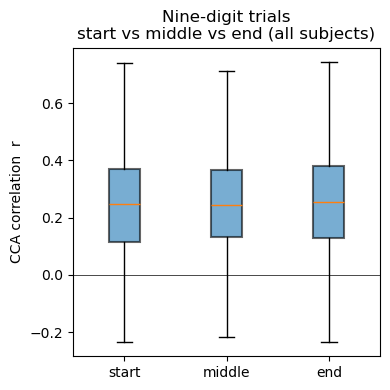


=== Repeated-measures ANOVA (within trials) ===
sum_sq    0.099228
df        2.000000
F         1.595945
PR(>F)    0.202838
Name: C(digit_pos), dtype: float64


In [46]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.stats.anova as sm_anova
import matplotlib.pyplot as plt

###############################################################################
# 1) Select the nine-digit memory trials only
###############################################################################
df9 = (df
       .query("condition == 'memory' and load == 9")
       .copy())

###############################################################################
# 2) Compute start / middle / end means *within every trial*  ---------------
#    First pivot so each row is one trial and each column a digit position
###############################################################################
wide = (df9
        .pivot_table(index=['subject', 'epoch'],   # one row = one trial
                     columns='digit_pos',
                     values='r',
                     aggfunc='mean'))

# drop trials that are missing any of the nine digit-windows
wide = wide.dropna()

# three group means per trial
wide['start']  = wide[[1, 2, 3]].mean(axis=1)
wide['middle'] = wide[[4, 5, 6]].mean(axis=1)
wide['end']    = wide[[7, 8, 9]].mean(axis=1)

###############################################################################
# 3) Inspect the per-trial numbers (optional) ---------------------------------
###############################################################################
print("\n=== First five trials (mean r per group) ===")
print(wide[['start', 'middle', 'end']].head())

###############################################################################
# 4) Plot the distribution across *all* trials --------------------------------
###############################################################################
plt.figure(figsize=(4, 4))
plt.boxplot(
    [wide['start'], wide['middle'], wide['end']],
    labels=['start', 'middle', 'end'],
    showfliers=False, patch_artist=True, boxprops=dict(alpha=0.6, lw=1.5)
)
plt.ylabel("CCA correlation  r")
plt.title("Nine-digit trials\nstart vs middle vs end (all subjects)")
plt.axhline(0, color='k', lw=.5)
plt.tight_layout()
plt.show()

###############################################################################
# 5) Repeated-measures ANOVA: start vs middle vs end  ------------------------
###############################################################################
# reshape to long form: one row = one trial-group value
long = wide[['start', 'middle', 'end']].stack().reset_index()
long = long.rename(columns={'level_2': 'group', 0: 'r'})

# add a numeric subject ID column for statsmodels
long['sub'] = long['subject'].astype('category').cat.codes

# rm-ANOVA with subject as random factor
model = smf.ols("r ~ C(digit_pos) + C(sub)", data=long).fit()
anova = sm_anova.anova_lm(model, typ=2)
print("\n=== Repeated-measures ANOVA (within trials) ===")
print(anova.loc["C(digit_pos)"])


In [47]:
from scipy.stats import ttest_rel, t
import numpy as np

start  = wide['start']
middle = wide['middle']
end    = wide['end']

# Calculate differences
diff_sm = middle - start
diff_me = end - middle
diff_se = end - start

# Perform t-tests
t_sm, p_sm = ttest_rel(start, middle, nan_policy='omit', alternative='less')
t_me, p_me = ttest_rel(middle, end,  nan_policy='omit', alternative='less')
t_se, p_se = ttest_rel(start, end,  nan_policy='omit', alternative='less')

# Calculate confidence intervals (95%)
def calculate_ci(diff):
    mean_diff = diff.mean()
    se_diff = diff.std(ddof=1) / np.sqrt(len(diff))
    df9 = len(diff) - 1
    ci_lower, ci_upper = t.interval(0.95, df9, loc=mean_diff, scale=se_diff)
    return mean_diff, ci_lower, ci_upper

mean_sm, ci_lower_sm, ci_upper_sm = calculate_ci(diff_sm)
mean_me, ci_lower_me, ci_upper_me = calculate_ci(diff_me)
mean_se, ci_lower_se, ci_upper_se = calculate_ci(diff_se)

print(f"middle vs start : t = {t_sm:.2f},  p = {p_sm:.3g}")
print(f"                  mean diff = {mean_sm:.3f}, 95% CI [{ci_lower_sm:.3f}, {ci_upper_sm:.3f}]")
print()
print(f"middle vs end   : t = {t_me:.2f},  p = {p_me:.3g}")
print(f"                  mean diff = {mean_me:.3f}, 95% CI [{ci_lower_me:.3f}, {ci_upper_me:.3f}]")
print()
print(f"start vs end    : t = {t_se:.2f},  p = {p_se:.3g}")
print(f"                  mean diff = {mean_se:.3f}, 95% CI [{ci_lower_se:.3f}, {ci_upper_se:.3f}]")


middle vs start : t = -0.05,  p = 0.478
                  mean diff = 0.000, 95% CI [-0.012, 0.013]

middle vs end   : t = -1.54,  p = 0.0615
                  mean diff = 0.010, 95% CI [-0.003, 0.023]

start vs end    : t = -1.54,  p = 0.0618
                  mean diff = 0.010, 95% CI [-0.003, 0.023]


In [50]:
df = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\df.csv")


=== First five trials (mean r per group) ===
digit_pos                 start    middle       end  super_end
subject epoch                                                 
sub-033 trial_003.csv  0.346196  0.293331  0.304799   0.350346
        trial_006.csv  0.001624  0.282451 -0.029580   0.175043
        trial_007.csv  0.325574  0.106721  0.166031   0.241869
        trial_014.csv  0.359013 -0.078738  0.216335  -0.116143
        trial_021.csv  0.092765  0.401918 -0.139935  -0.107308


C:\Users\cdd\AppData\Local\Temp\ipykernel_29568\1046154272.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


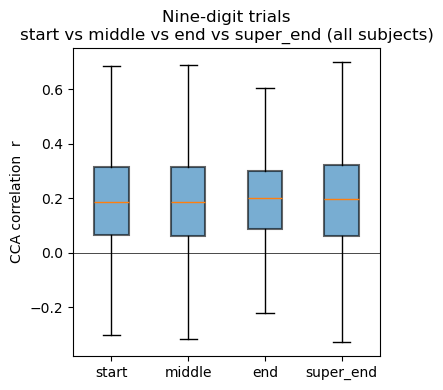


=== Repeated-measures ANOVA (within trials) ===
sum_sq    0.150767
df        3.000000
F         1.599608
PR(>F)    0.187262
Name: C(digit_pos), dtype: float64


In [51]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.stats.anova as sm_anova
import matplotlib.pyplot as plt

###############################################################################
# 1) Select the nine-digit memory trials only
###############################################################################
df13 = (df
       .query("condition == 'memory' and load == 13")
       .copy())

###############################################################################
# 2) Compute start / middle / end means *within every trial*  ---------------
#    First pivot so each row is one trial and each column a digit position
###############################################################################
wide = (df13
        .pivot_table(index=['subject', 'epoch'],   # one row = one trial
                     columns='digit_pos',
                     values='r',
                     aggfunc='mean'))

# drop trials that are missing any of the nine digit-windows
wide = wide.dropna()

# three group means per trial
wide['start']  = wide[[1, 2, 3]].mean(axis=1)
wide['middle'] = wide[[4, 5, 6]].mean(axis=1)
wide['end']    = wide[[7, 8, 9, 10]].mean(axis=1)
wide['super_end'] = wide[[11, 12, 13]].mean(axis=1)

###############################################################################
# 3) Inspect the per-trial numbers (optional) ---------------------------------
###############################################################################
print("\n=== First five trials (mean r per group) ===")
print(wide[['start', 'middle', 'end', 'super_end']].head())

###############################################################################
# 4) Plot the distribution across *all* trials --------------------------------
###############################################################################
plt.figure(figsize=(4, 4))
plt.boxplot(
    [wide['start'], wide['middle'], wide['end'], wide['super_end']],
    labels=['start', 'middle', 'end', 'super_end'],
    showfliers=False, patch_artist=True, boxprops=dict(alpha=0.6, lw=1.5)
)
plt.ylabel("CCA correlation  r")
plt.title("Nine-digit trials\nstart vs middle vs end vs super_end (all subjects)")
plt.axhline(0, color='k', lw=.5)
plt.tight_layout()
plt.show()

###############################################################################
# 5) Repeated-measures ANOVA: start vs middle vs end  ------------------------
###############################################################################
# reshape to long form: one row = one trial-group value
long = wide[['start', 'middle', 'end', 'super_end']].stack().reset_index()
long = long.rename(columns={'level_2': 'group', 0: 'r'})

# add a numeric subject ID column for statsmodels
long['sub'] = long['subject'].astype('category').cat.codes

# rm-ANOVA with subject as random factor
model = smf.ols("r ~ C(digit_pos) + C(sub)", data=long).fit()
anova = sm_anova.anova_lm(model, typ=2)
print("\n=== Repeated-measures ANOVA (within trials) ===")
print(anova.loc["C(digit_pos)"])


In [52]:
from scipy.stats import ttest_rel, t
import numpy as np

start  = wide['start']
middle = wide['middle']
end    = wide['end']
super_end = wide['super_end']

# Calculate differences
diff_sm = middle - start
diff_se = end - start
diff_sse = super_end - start
diff_me = end - middle
diff_mse = super_end - middle
diff_ese = super_end - end



# Perform t-tests
t_sm, p_sm = ttest_rel(start, middle, nan_policy='omit', alternative='less')
t_se, p_se = ttest_rel(start, end,  nan_policy='omit', alternative='less')
t_sse, p_sse = ttest_rel(start, super_end,  nan_policy='omit', alternative='less')
t_me, p_me = ttest_rel(middle, end,  nan_policy='omit', alternative='less')
t_mse, p_mse = ttest_rel(middle, super_end,  nan_policy='omit', alternative='less')
t_ese, p_ese = ttest_rel(end, super_end,  nan_policy='omit', alternative='less')

# Calculate confidence intervals (95%)
def calculate_ci(diff):
    mean_diff = diff.mean()
    se_diff = diff.std(ddof=1) / np.sqrt(len(diff))
    df9 = len(diff) - 1
    ci_lower, ci_upper = t.interval(0.95, df9, loc=mean_diff, scale=se_diff)
    return mean_diff, ci_lower, ci_upper

mean_sm, ci_lower_sm, ci_upper_sm = calculate_ci(diff_sm)
mean_se, ci_lower_se, ci_upper_se = calculate_ci(diff_se)
mean_sse, ci_lower_sse, ci_upper_sse = calculate_ci(diff_sse)
mean_me, ci_lower_me, ci_upper_me = calculate_ci(diff_me)
mean_mse, ci_lower_mse, ci_upper_mse = calculate_ci(diff_mse)
mean_ese, ci_lower_ese, ci_upper_ese = calculate_ci(diff_ese)

print(f"middle vs start : t = {t_sm:.2f},  p = {p_sm:.3g}")
print(f"                  mean diff = {mean_sm:.3f}, 95% CI [{ci_lower_sm:.3f}, {ci_upper_sm:.3f}]")
print()
print(f"start vs end    : t = {t_se:.2f},  p = {p_se:.3g}")
print(f"                  mean diff = {mean_se:.3f}, 95% CI [{ci_lower_se:.3f}, {ci_upper_se:.3f}]")
print()
print(f"start vs super_end: t = {t_sse:.2f},  p = {p_sse:.3g}")
print(f"                  mean diff = {mean_sse:.3f}, 95% CI [{ci_lower_sse:.3f}, {ci_upper_sse:.3f}]")
print()
print(f"middle vs end   : t = {t_me:.2f},  p = {p_me:.3g}")
print(f"                  mean diff = {mean_me:.3f}, 95% CI [{ci_lower_me:.3f}, {ci_upper_me:.3f}]")
print()
print(f"middle vs super_end: t = {t_mse:.2f},  p = {p_mse:.3g}")
print(f"                  mean diff = {mean_mse:.3f}, 95% CI [{ci_lower_mse:.3f}, {ci_upper_mse:.3f}]")
print()
print(f"end vs super_end: t = {t_ese:.2f},  p = {p_ese:.3g}")
print(f"                  mean diff = {mean_ese:.3f}, 95% CI [{ci_lower_ese:.3f}, {ci_upper_ese:.3f}]")

middle vs start : t = -0.09,  p = 0.465
                  mean diff = 0.001, 95% CI [-0.013, 0.014]

start vs end    : t = -1.62,  p = 0.0524
                  mean diff = 0.010, 95% CI [-0.002, 0.023]

start vs super_end: t = -1.56,  p = 0.0595
                  mean diff = 0.011, 95% CI [-0.003, 0.024]

middle vs end   : t = -1.56,  p = 0.0599
                  mean diff = 0.010, 95% CI [-0.003, 0.022]

middle vs super_end: t = -1.51,  p = 0.0655
                  mean diff = 0.010, 95% CI [-0.003, 0.023]

end vs super_end: t = -0.06,  p = 0.478
                  mean diff = 0.000, 95% CI [-0.012, 0.012]
